<a href="https://colab.research.google.com/github/imredi12/Challenge_TelecomX2/blob/main/Desafio_TelecomX2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Preparación de datos

##Carga de datos

In [2]:
datos=pd.read_csv('/content/datos_clientes.csv')

In [3]:
datos.head()

,ID_cliente,Evasión,genero,adulto,pareja,dependientes,meses_cliente,servicio_telefono,multiples_lineas,servicio_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_digital,metodo_pago,cargo_mensual,cargo_total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


Se va a depurar la tabla de datos de columnas irrelevantes que pueden perjudicar el análisis para la predicción de la canelación

In [4]:
pd.set_option('display.max_columns', None)
datos.head()

,ID_cliente,Evasión,genero,adulto,pareja,dependientes,meses_cliente,servicio_telefono,multiples_lineas,servicio_internet,seguridad_online,respaldo_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_digital,metodo_pago,cargo_mensual,cargo_total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


##Eliminación de columnas

In [5]:
datos.nunique()

,0
ID_cliente,7267
Evasión,2
genero,2
adulto,2
pareja,2
dependientes,2
meses_cliente,73
servicio_telefono,2
multiples_lineas,2
servicio_internet,3


Para la depuración de las columnas que no son relevantes se siguieron los siguientes criterios:

Se identificaron las columnas que:

1.	No aportan información predictiva

2.	Son identificadores únicos

3.	Provocan fuga de información (data leakage)

4.	Son redundantes o derivadas de otras

La primera como se indica en las instrucciones es la de ID_cliente, es un indicador único y no aporta información para el modelo predictivo

Hay otras columnas derivadas como la de cargo_total ≈ meses_cliente × cargo_mensual y la que se pidió crear de cargo diario.

Primero elimié cargo total pero más abajo se pidió correlación de evasión Vs cargo total así que lo volví a poner pero cargo diario si lo quito.

In [6]:
col_relev = [
'Evasión',
'genero',
'adulto',
'pareja',
'dependientes',
'meses_cliente',
'servicio_telefono',
'multiples_lineas',
'servicio_internet',
'seguridad_online',
'respaldo_online',
'proteccion_dispositivo',
'soporte_tecnico',
'streaming_tv',
'streaming_peliculas',
'tipo_contrato',
'facturacion_digital',
'metodo_pago',
'cargo_mensual',
'cargo_total'
]

datos = datos[col_relev]

In [7]:
datos.head()

,Evasión,genero,adulto,pareja,dependientes,meses_cliente,servicio_telefono,multiples_lineas,servicio_internet,seguridad_online,respaldo_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_digital,metodo_pago,cargo_mensual,cargo_total
0,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30
1,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40
2,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40


In [8]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Evasión                 7267 non-null   int64  
 1   genero                  7267 non-null   object 
 2   adulto                  7267 non-null   int64  
 3   pareja                  7267 non-null   int64  
 4   dependientes            7267 non-null   int64  
 5   meses_cliente           7267 non-null   int64  
 6   servicio_telefono       7267 non-null   int64  
 7   multiples_lineas        7267 non-null   int64  
 8   servicio_internet       7267 non-null   object 
 9   seguridad_online        7267 non-null   int64  
 10  respaldo_online         7267 non-null   int64  
 11  proteccion_dispositivo  7267 non-null   int64  
 12  soporte_tecnico         7267 non-null   int64  
 13  streaming_tv            7267 non-null   int64  
 14  streaming_peliculas     7267 non-null   

##Encoding

Una vez que ya se tienen las columnas que son importantes para el análisis se procede a cambiar las columnas categóricas (object) a numéricas binarias.

Se pone en práctica el método One-Hot Encoding con el dummy


In [9]:
col_categ = datos.select_dtypes(include=['object']).columns
col_categ

Index(['genero', 'servicio_internet', 'tipo_contrato', 'metodo_pago'], dtype='object')

In [10]:
col_categ = datos.select_dtypes(include=['object']).columns
datos_encoded = (pd.get_dummies(datos, columns=col_categ, drop_first=True)).astype(int)
datos_encoded.head()

,Evasión,adulto,pareja,dependientes,meses_cliente,servicio_telefono,multiples_lineas,seguridad_online,respaldo_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,facturacion_digital,cargo_mensual,cargo_total,genero_Male,servicio_internet_Fiber optic,servicio_internet_No,tipo_contrato_One year,tipo_contrato_Two year,metodo_pago_Credit card (automatic),metodo_pago_Electronic check,metodo_pago_Mailed check
0,0,0,1,1,9,1,0,0,1,0,1,1,0,1,65,593,0,0,0,1,0,0,0,1
1,0,0,0,0,9,1,1,0,0,0,0,0,1,0,59,542,1,0,0,0,0,0,0,1
2,1,0,0,0,4,1,0,0,0,1,0,0,0,1,73,280,1,1,0,0,0,0,1,0
3,1,1,1,0,13,1,0,0,1,1,0,1,1,1,98,1237,1,1,0,0,0,0,1,0
4,1,1,1,0,3,1,0,0,0,0,1,1,0,1,83,267,0,1,0,0,0,0,0,1


## Verificación de Evasión

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.


In [11]:
datos['Evasión'].value_counts()
datos['Evasión'].value_counts(normalize=True) * 100

,proportion
Evasión,
0,74.280996
1,25.719004


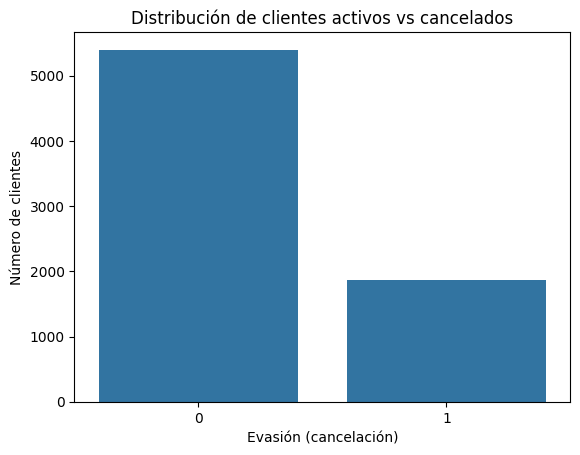

In [12]:
#Una visualización rápida

sns.countplot(x='Evasión', data=datos)

plt.title('Distribución de clientes activos vs cancelados')
plt.xlabel('Evasión (cancelación)')
plt.ylabel('Número de clientes')
plt.show()

## Balanceo de clases

Como se aprendió cuando hay un desbalanceo de proporicones, en este caso 74% de cumplidos y 25% de incumplidos lo que se nos recomendó es hacer un balanceo ya sea usando undersampling u oversampling.

En mis datos se obssrva un desbalanceo haré oversampling para que los datos de los que cancelan sean la misma cantidad de los que se quedan

In [13]:
X = datos_encoded.drop('Evasión', axis=1)
y = datos_encoded['Evasión']

In [14]:
# Divido mis datos para el modelo

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [15]:
#aplico el SMOTE para oversampling

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [16]:
#para verificar que mis datos ahora esten balanceados
y_train.value_counts()

,count
Evasión,
0,3778
1,1308


In [17]:
y_train_smote.value_counts()

,count
Evasión,
0,3778
1,3778


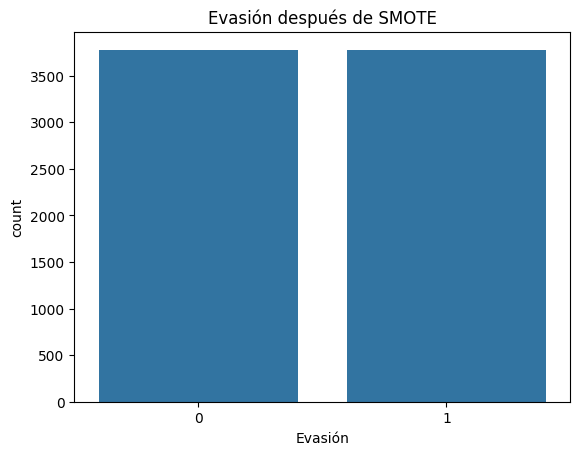

In [18]:
sns.countplot(x=y_train_smote)
plt.title('Evasión después de SMOTE')
plt.show()

## Normalización o Estandarización

Evalúa la necesidad de normalizar o estandarizar los datos, según los modelos que se aplicarán. Modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, requieren este preprocesamiento. Por otro lado, modelos basados en árboles, como Decision Tree, Random Forest y XGBoost, no son sensibles a la escala de los datos.

Para decidir si normalizar o estandarizar los datos, dependerá de  qué algoritmos se van a usar, porque no todos usan la misma escala de las variables.

Voy a usar regresion lineal primero y luego random forest que son los que me gustaron más.



In [19]:
#Normalización con StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

#Correlación y Selección de Variables

##Análisis de Correlación

Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

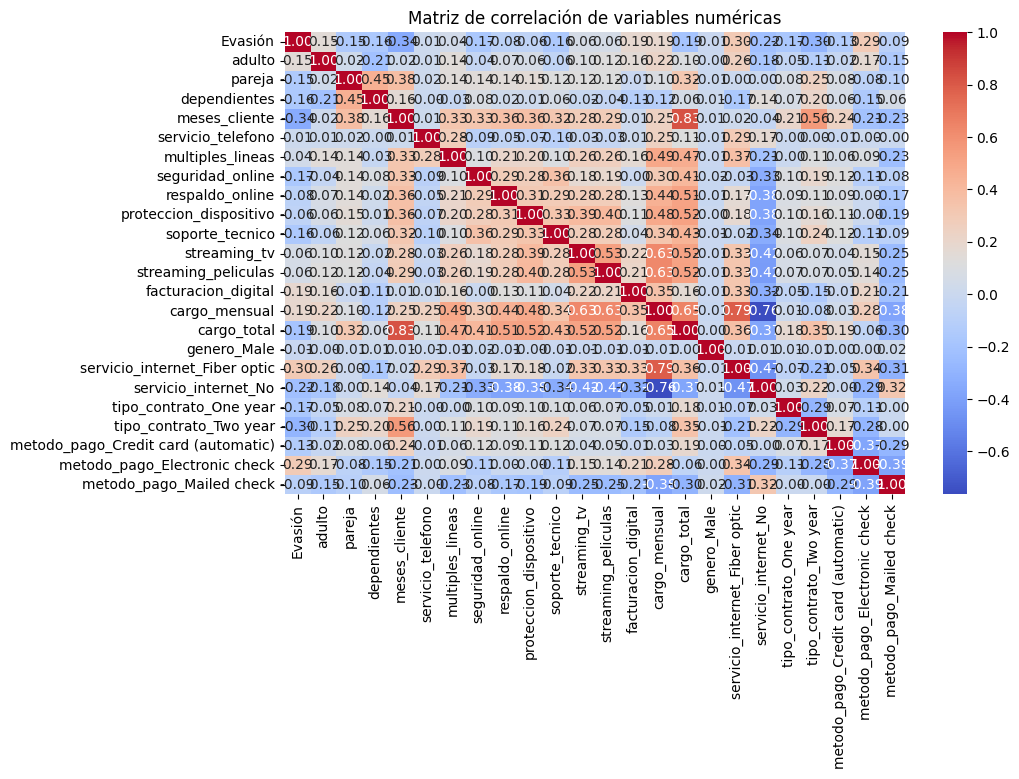

In [20]:
#Para generar la matriz de confusion bonita de colores
datos_num = datos_encoded.select_dtypes(include=['int64','float64'])

#se crea la matriz

correlacion = datos_num.corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlación de variables numéricas')
plt.show()



In [21]:
correlacion['Evasión'].sort_values(ascending=False)

,Evasión
Evasión,1.000000
servicio_internet_Fiber optic,0.300949
metodo_pago_Electronic check,0.294626
cargo_mensual,0.189907
facturacion_digital,0.186666
adulto,0.146733
streaming_tv,0.062430
streaming_peliculas,0.060586
multiples_lineas,0.039343
servicio_telefono,0.012571


Del análsis de correlación se observa que pagos mensuales elevados causan cancelación, así como contratos cortos, emtre más meses de cliente menos probabilidad de cancelar.

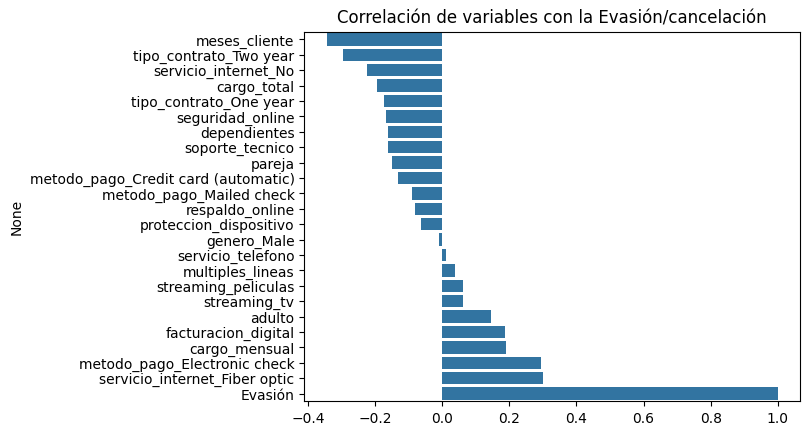

In [22]:
#si quiero visualizar solo para la Evasión

sns.barplot(
    x=correlacion['Evasión'].sort_values().values,
    y=correlacion['Evasión'].sort_values().index
)

plt.title('Correlación de variables con la Evasión/cancelación')
plt.show()

##Análisis Dirigido

Investiga cómo variables específicas se relacionan con la cancelación, tales como:

    Tiempo de contrato × Cancelación

    Gasto total × Cancelación

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

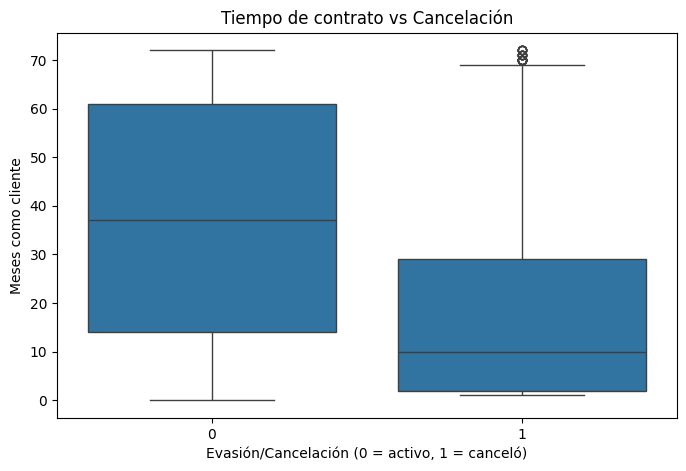

In [23]:
#Primero quiero analizar cómo se correlaciona el tiempo de servicio en meses con la cancelación

plt.figure(figsize=(8,5))

sns.boxplot(x='Evasión', y='meses_cliente', data=datos)

plt.title('Tiempo de contrato vs Cancelación')
plt.xlabel('Evasión/Cancelación (0 = activo, 1 = canceló)')
plt.ylabel('Meses como cliente')
plt.show()

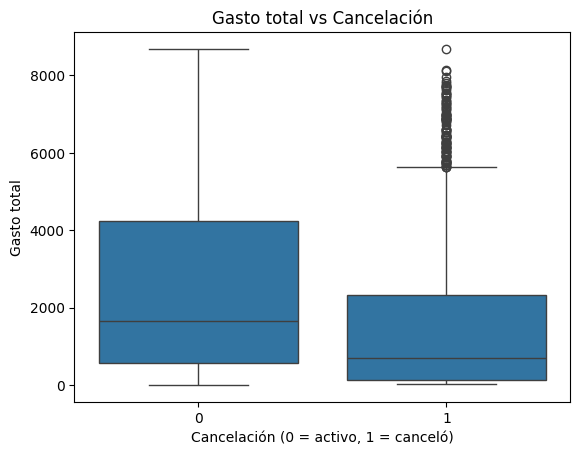

In [24]:
#Ahora Gasto total contra Evasión

sns.boxplot(x='Evasión', y='cargo_total', data=datos)

plt.title('Gasto total vs Cancelación')
plt.xlabel('Cancelación (0 = activo, 1 = canceló)')
plt.ylabel('Gasto total')
plt.show()



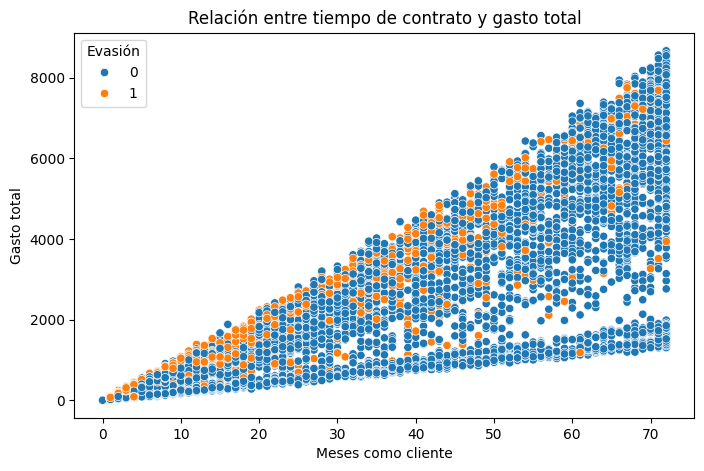

In [25]:
#ahora usando scatter plots

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='meses_cliente',
    y='cargo_total',
    hue='Evasión',
    data=datos
)

plt.title('Relación entre tiempo de contrato y gasto total')
plt.xlabel('Meses como cliente')
plt.ylabel('Gasto total')
plt.show()

Pues si, se confirma que a menor tiempo y gasto es mayor el número de cancelaciones

Se me ocurre ver como se comporta la evasión pero en periodos, se que a menor palzo mas evasión pero para poner en práctica


/tmp/ipykernel_168/1626631700.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  datos.groupby('rango_tiempo')['Evasión']


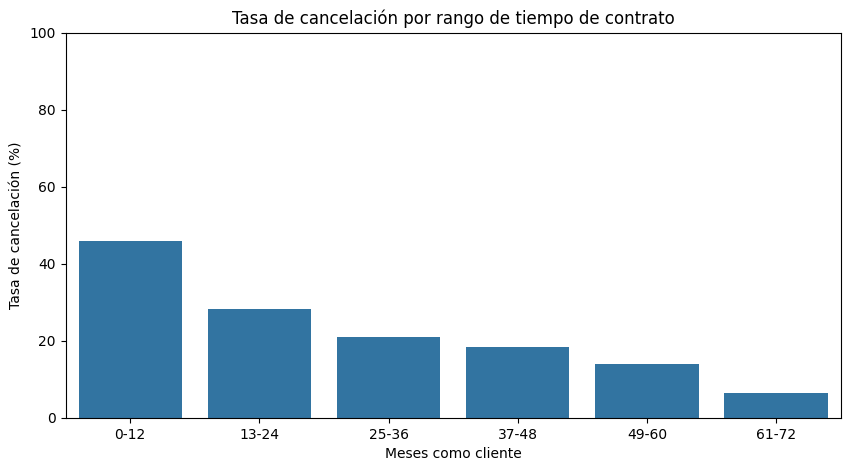

In [26]:
datos['rango_tiempo'] = pd.cut(
    datos['meses_cliente'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72'],
    include_lowest=True
)

tasa_cancelacion = (
    datos.groupby('rango_tiempo')['Evasión']
    .mean()
    .reset_index()
)

# no me gusto en valores absolutos mejor en poercentaje

tasa_cancelacion['Evasión'] = tasa_cancelacion['Evasión'] * 100

plt.figure(figsize=(10, 5))
sns.barplot(data=tasa_cancelacion, x='rango_tiempo', y='Evasión')

plt.title('Tasa de cancelación por rango de tiempo de contrato')
plt.xlabel('Meses como cliente')
plt.ylabel('Tasa de cancelación (%)')
plt.ylim(0, 100)
plt.show()

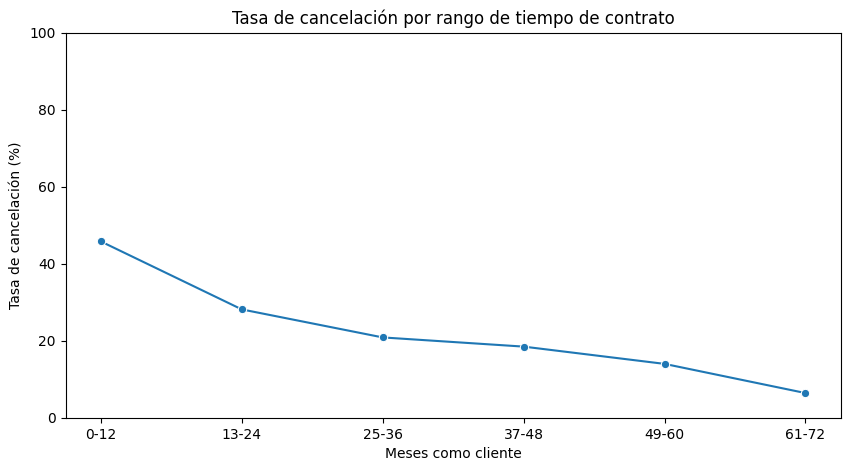

In [27]:
# con una linea en lugar de barras

plt.figure(figsize=(10, 5))
sns.lineplot(data=tasa_cancelacion, x='rango_tiempo', y='Evasión', marker='o')

plt.title('Tasa de cancelación por rango de tiempo de contrato')
plt.xlabel('Meses como cliente')
plt.ylabel('Tasa de cancelación (%)')
plt.ylim(0, 100)
plt.show()

#Modelado Predictivo

##Separación de datos

Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

In [28]:
#Usare la dicvisón de 70 - 30 con el método train_test_split

X = datos_encoded.drop('Evasión', axis=1)
y = datos_encoded['Evasión']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,      # 30% para prueba
    random_state=42,    # para asegurar buena repetitividad
    stratify=y          # mantiene proporción de clases
)


In [29]:
#para verificar que si se tengan los tamaños elegidos

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (5086, 23)
Prueba: (2181, 23)


In [30]:
#tambien se recomienda verificar que las clases esten bien distribuidas

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Evasión
0    0.742823
1    0.257177
Name: proportion, dtype: float64
Evasión
0    0.742779
1    0.257221
Name: proportion, dtype: float64


##Creación de Modelos

Debo hacer el análisis con los datos balanceados, arriba ya hice el SMOTE

In [31]:
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

#Primero con regresion logistica

from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train_scaled, y_train_smote)

y_pred = modelo.predict(X_test_scaled)

from sklearn.metrics import classification_report, confusion_matrix

print("Matriz de confusión")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación")
print(classification_report(y_test, y_pred))

Matriz de confusión
[[1328  292]
 [ 192  369]]

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1620
           1       0.56      0.66      0.60       561

    accuracy                           0.78      2181
   macro avg       0.72      0.74      0.72      2181
weighted avg       0.79      0.78      0.78      2181



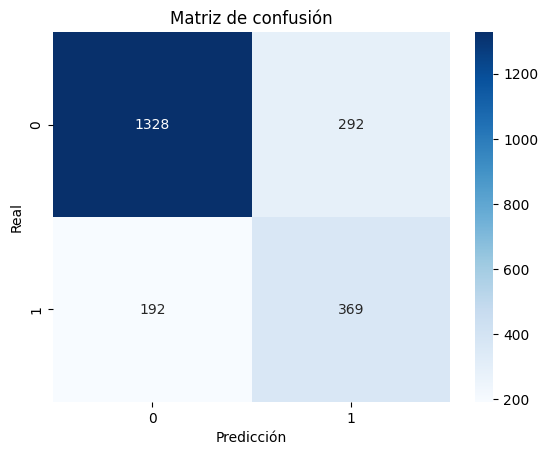

In [32]:
#Me gusta mucho ver la matríz de confusión

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión')
plt.show()

In [33]:
#ahora con random forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)
y_pred_rf = rf_model.predict(X_test)          #random forest no requiere el escalamiento

In [34]:
from sklearn.metrics import classification_report, confusion_matrix

print("Matriz de confusión")
print(confusion_matrix(y_test, y_pred_rf))

print("\nReporte de clasificación")
print(classification_report(y_test, y_pred_rf))

Matriz de confusión
[[1349  271]
 [ 238  323]]

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1620
           1       0.54      0.58      0.56       561

    accuracy                           0.77      2181
   macro avg       0.70      0.70      0.70      2181
weighted avg       0.77      0.77      0.77      2181



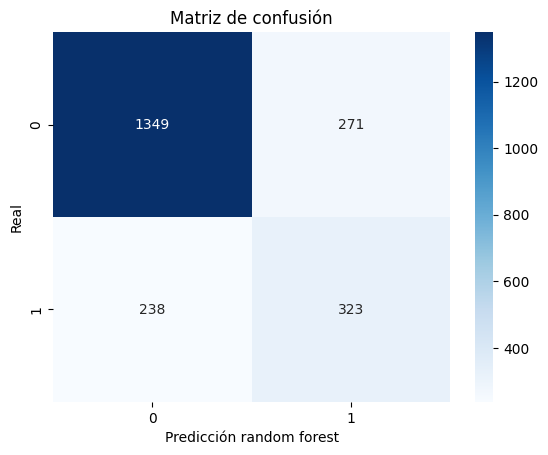

In [35]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicción random forest')
plt.ylabel('Real')
plt.title('Matriz de confusión')
plt.show()

##Evaluación de los Modelos

Evalúa cada modelo utilizando las siguientes métricas:

    Exactitud (Acurácia)

    Precisión

    Recall

    F1-score

    Matriz de confusión

Después, realiza un análisis crítico y compara los modelos:

    ¿Cuál modelo tuvo el mejor desempeño?

    ¿Algún modelo presentó overfitting o underfitting? Si es así, considera las posibles causas y ajustes:

        Overfitting: Cuando el modelo aprende demasiado sobre los datos de entrenamiento, perdiendo la capacidad de generalizar a nuevos datos. Considera reducir la complejidad del modelo o aumentar los datos de entrenamiento.

        Underfitting: Cuando el modelo no captura bien las tendencias de los datos, lo que indica que es demasiado simple. Intenta aumentar la complejidad del modelo o ajustar sus parámetros.

In [36]:
# para evaluar amnbos modelos utilizados

from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, y_pred))

print("\nRandom Forest")
print(classification_report(y_test, y_pred_rf))

Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1620
           1       0.56      0.66      0.60       561

    accuracy                           0.78      2181
   macro avg       0.72      0.74      0.72      2181
weighted avg       0.79      0.78      0.78      2181


Random Forest
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1620
           1       0.54      0.58      0.56       561

    accuracy                           0.77      2181
   macro avg       0.70      0.70      0.70      2181
weighted avg       0.77      0.77      0.77      2181



In [37]:
# La Exactitud

from sklearn.metrics import accuracy_score

print("Exactitud Regresion Logistica:", accuracy_score(y_test, y_pred))
print("Exactitud Random Forest:", accuracy_score(y_test, y_pred_rf))

Exactitud Regresion Logistica: 0.7780834479596516
Exactitud Random Forest: 0.7666208161393856


#Interpretación y Conclusiones

##Análisis de la Importancia de las Variables

In [38]:
#para saber cuales son las variables mas importantes que consideró de random forest

importancias = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias.head(10))

cargo_total                      0.143643
meses_cliente                    0.142046
cargo_mensual                    0.122497
tipo_contrato_Two year           0.074134
soporte_tecnico                  0.047316
tipo_contrato_One year           0.046232
servicio_internet_Fiber optic    0.038968
dependientes                     0.038744
seguridad_online                 0.038024
pareja                           0.036500
dtype: float64


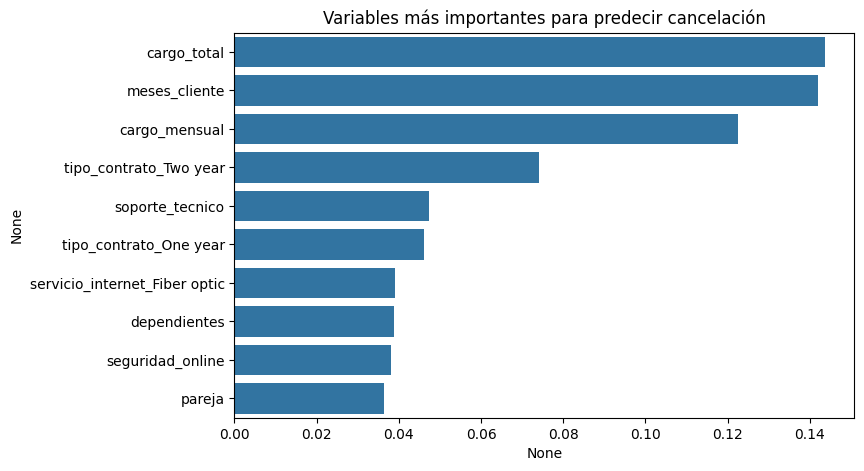

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(x=importancias.head(10), y=importancias.head(10).index)

plt.title("Variables más importantes para predecir cancelación")
plt.show()

Voy a probar con XGBoost

In [40]:
!pip install xgboost

import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# los siguientes parametros los copie de la literatura, son los recomendados

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_model.predict(X_test)

In [41]:
#Evaluendo el modelo

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nMatriz de confusión")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nReporte de clasificación")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7757909215955984

Matriz de confusión
[[1335  285]
 [ 204  357]]

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1620
           1       0.56      0.64      0.59       561

    accuracy                           0.78      2181
   macro avg       0.71      0.73      0.72      2181
weighted avg       0.79      0.78      0.78      2181



In [42]:
importancias = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias.head(10))

tipo_contrato_Two year                 0.315699
tipo_contrato_One year                 0.240636
servicio_internet_No                   0.093929
metodo_pago_Mailed check               0.040834
soporte_tecnico                        0.035250
dependientes                           0.034781
metodo_pago_Credit card (automatic)    0.029915
pareja                                 0.027139
seguridad_online                       0.026276
respaldo_online                        0.021583
dtype: float32


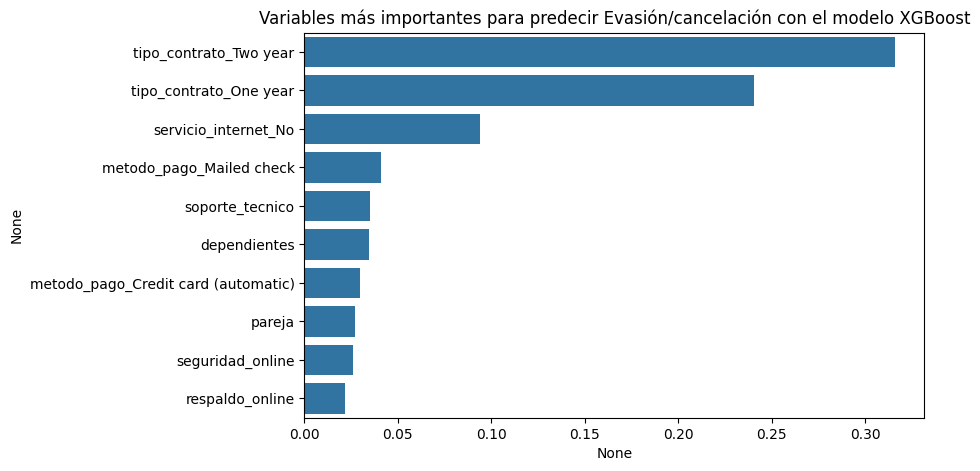

In [43]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=importancias.head(10),
    y=importancias.head(10).index
)

plt.title("Variables más importantes para predecir Evasión/cancelación con el modelo XGBoost")
plt.show()

##Conclusión

Informe Final

Introducción

El objetivo de este proyecto fue identificar los factores que más influyen en la Evasión/cancelación de clientes, poniendo en práctica modelos predictivos capaces de anticipar qué clientes presentan mayor probabilidad de evasión.
A partir del análisis de las métricas obtenidas se proponen estrategias de retención para disminuir la pérdida de clientes.
Para este propósito se trabajó con un conjunto de datos de clientes de desde una base de datos ya trabajada anteriormente, esta base de datos corresponde a una empresa de telecomunicaciones, que incluye variables del servicio contratado, condiciones de facturación, cargos mensuales y acumulados.

Desarrollo

Primero se realizó una etapa de preparación, depuración y transformación de los datos, que incluyó:

•	Limpieza y revisión de inconsistencias

•	Renombrado de columnas para facilitar el análisis

•	Conversión de variables categóricas a formato numérico
mediante One-Hot Encoding

•	Análisis de variable objetivo (Evasión)

Después se comprobó el balance de los datos y se aplicó SMOTE, para así comenzar con la fase de modelado, para ello una vez balanceados, se dividió el conjunto de datos en: 70% entrenamiento y 30% prueba.
Se usaron primeramente dos modelos, Logistic Regression  y Random Forest, al final use también XGBoost.

De los resultados obtenidos, se encontraron patrones de cancelación muy evidentes respecto a:

-	Tiempo de contrato Vs cancelación: Se observó que los clientes con menor antigüedad presentan una mayor tasa de cancelación. En los gráficos de boxplot y en los análisis por rangos de tiempo de contrato, la evasión fue más frecuente en clientes con pocos meses de permanencia.
-	Gasto total y cancelación: El gasto total acumulado mostró una relación inversa con la cancelación. Los clientes que permanecen por más tiempo suelen tener un mayor gasto total, mientras que quienes cancelan presentan valores acumulados menores.
-	Cargo mensual y cancelación: El cargo mensual mostró una relación positiva con la cancelación: clientes con cargos mensuales más altos tienden a cancelar con mayor frecuencia.
-	Tipo de contrato: El tipo de contrato fue uno de los factores más relevantes. Los clientes con contratos mensuales tienden a presentar mayores tasas de cancelación que aquellos con contratos anuales o bianuales.
-	Método de pago: El método de pago también mostró asociación con la cancelación. En particular, algunos métodos como el pago electrónico manual suelen presentar una tasa de cancelación mayor que los métodos automáticos.
-	Servicios adicionales: Variables como soporte técnico, seguridad online, respaldo online y protección del dispositivo pueden ayudar a diferenciar a los clientes que permanecen de los que cancelan, pero en una menor escala.
En cuanto a los modelos utilizados.
La Regresión Logística obtuvo menor desempeño, Random Forest mejoró un poco las métricas; y XGBoost mostró el mejor recall y F1-score para la clase de Evasión, entonces es el mejor candidato para un sistema de alerta temprana.
Factores que más influyen en la cancelación
A partir del análisis exploratorio y del comportamiento de los modelos, los factores con mayor influencia sobre la cancelación son:
1.	Antigüedad del cliente (meses_cliente), a mayor antigüedad menor cancelación.
2.	Tipo de contrato (tipo_contrato), contratos mensuales presentan mayor riesgo de cancelación que los contratos de mayor plazo.
3.	Cargo mensual (cargo_mensual), clientes con cargos mensuales más altos tienden a cancelar con mayor frecuencia.
4.	Gasto total (cargo_total), el gasto total acumulado suele estar negativamente relacionado con la cancelación.
5.	Método de pago (metodo_pago), El pago con cheque electrónico es el que más cancelación tuvo, sugiriendo que por ejemplo pago domiciliado sea una mejor alternativa.


Propuestas para retener a los clientes

1.	Se debe incentivar contratos de mayor duración, ya que los contratos mensuales concentran la mayor tasa de cancelación, pueden dar descuentos por permanencia o agregar algunos servicios extras.
2.	Dar un seguimiento a los clientes con cargos mensuales altos ya que son los que tienen mayor riesgo de cancelar.
3.	Promover los pagos automáticos, así cuestiones como olvidar pagar a tiempo será menos frecuente.
4.	Fomentar más agregar otros servicios y que sean de valor

Conclusiones

El análisis realizado permitió identificar que la cancelación de clientes no ocurre al azar, sino que está asociada a patrones específicos en variables de tiempo de servicio, tipo de contrato y servicios contratados.

Los factores más determinantes para cancelación fueron:

•	menor tiempo de contrato

•	contratos mensuales

•	mayores cargos mensuales

•	menor gasto acumulado

•	ciertos métodos de pago

•	menor adopción de servicios complementarios

En cuanto a los modelos predictivos, la comparación entre Regresión Logística, Random Forest y XGBoost permitió concluir que los modelos basados en árboles ofrecen mejores métricas, XGBoost tuvo mejor recall y F1-score.

Finalmente, los hallazgos del análisis permiten traducirse en estrategias concretas de negocio, especialmente dirigidas a:

•	retener clientes en etapa temprana

•	promover contratos de mayor duración

•	revisar clientes con cargos mensuales altos

•	reducir fricción en métodos de pago

•	aumentar el valor percibido del servicio
